1. Delete id

2. Convert num → target

3. Handle missing values

4. Encode categorical variables

5. (X (features), y (target))

6. train_test_split

7. StandardScaler

8. LogisticRegression

9. Accuracy

10. Precision

11. Recall

12. F1

13. Confusion Matrix



# Download the Heart Disease UCI dataset

In [2]:
import pandas as pd

df = pd.read_csv('heart_disease_uci.csv')

df.head()


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


# EDA (Exploratory Data Analysis)

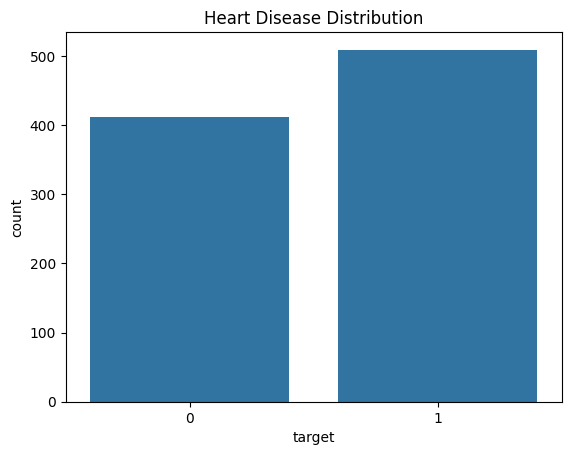

In [39]:
# Visualize target distribution
sns.countplot(x='target', data=df)

plt.title('Heart Disease Distribution')
plt.show()


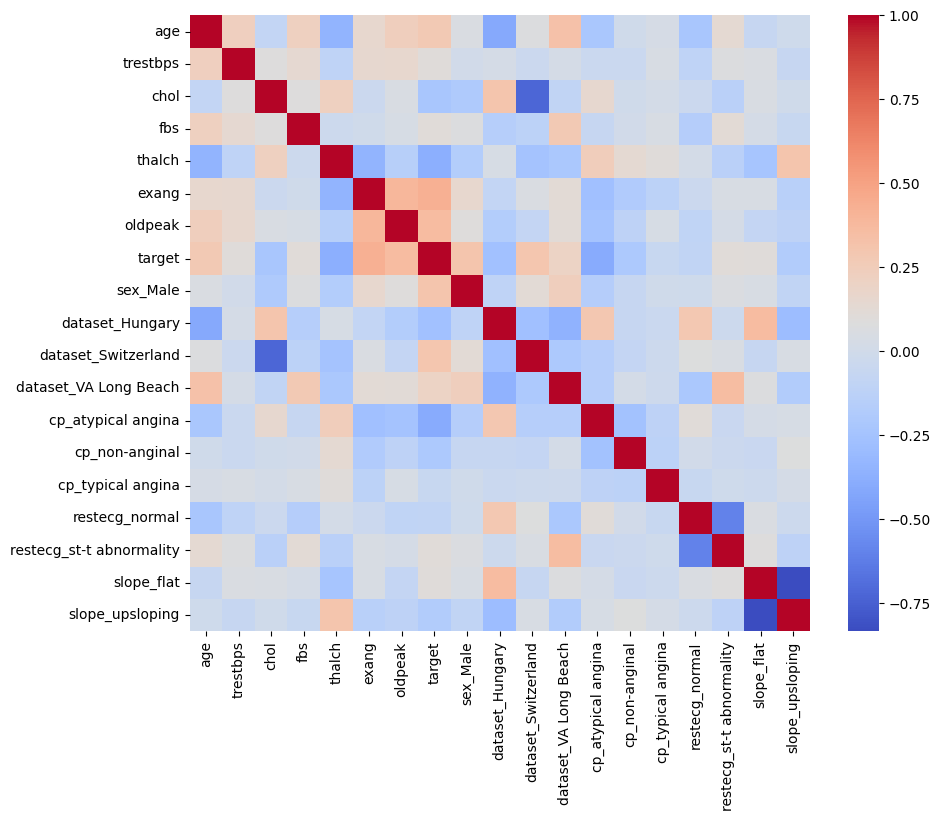

In [36]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [4]:
df.shape


(920, 16)

In [5]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [6]:
df['num'].value_counts()

,count
num,
0,411
1,265
2,109
3,107
4,28


# Preprocessing

In [7]:
df['target'] = (df['num'] > 0).astype(int)
df['target'].value_counts()

,count
target,
1,509
0,411


In [8]:
df.drop(['id', 'num'], axis=1, inplace=True)
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   dataset   920 non-null    object 
 3   cp        920 non-null    object 
 4   trestbps  861 non-null    float64
 5   chol      890 non-null    float64
 6   fbs       830 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    865 non-null    float64
 9   exang     865 non-null    object 
 10  oldpeak   858 non-null    float64
 11  slope     611 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
 14  target    920 non-null    int64  
dtypes: float64(5), int64(2), object(8)
memory usage: 107.9+ KB


In [10]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

,0
ca,66.413043
thal,52.826087
slope,33.586957
fbs,9.782609
oldpeak,6.739130
trestbps,6.413043
thalch,5.978261
exang,5.978261
chol,3.260870
restecg,0.217391


In [11]:
df.drop(['ca', 'thal'], axis=1, inplace=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   dataset   920 non-null    object 
 3   cp        920 non-null    object 
 4   trestbps  861 non-null    float64
 5   chol      890 non-null    float64
 6   fbs       830 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    865 non-null    float64
 9   exang     865 non-null    object 
 10  oldpeak   858 non-null    float64
 11  slope     611 non-null    object 
 12  target    920 non-null    int64  
dtypes: float64(4), int64(2), object(7)
memory usage: 93.6+ KB


In [13]:
# Fill missing values in numerical columns with median (the value that is in the middle after sorting)
numerical_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill missing values in categorical columns with mode (most frequent value)
categorical_cols = ['fbs', 'restecg', 'exang', 'slope']

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_2550/3623748920.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_2550/3623748920.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [14]:
df.isnull().sum()

,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0


In [15]:
# Convert categorical variables into numerical dummy variables
# drop_first=True removes one category from each group to avoid redundancy
df = pd.get_dummies(df, drop_first=True)

# Display the first 5 rows after encoding
df.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,target,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping
0,63,145.0,233.0,True,150.0,False,2.3,0,True,False,False,False,False,False,True,False,False,False,False
1,67,160.0,286.0,False,108.0,True,1.5,1,True,False,False,False,False,False,False,False,False,True,False
2,67,120.0,229.0,False,129.0,True,2.6,1,True,False,False,False,False,False,False,False,False,True,False
3,37,130.0,250.0,False,187.0,False,3.5,0,True,False,False,False,False,True,False,True,False,False,False
4,41,130.0,204.0,False,172.0,False,1.4,0,False,False,False,False,True,False,False,False,False,False,True


dataset_Cleavland removed, so it is now a basic class - means all others will be compared with it

In [16]:
df.shape

(920, 19)

In [17]:
# Check data types after encoding
df.dtypes

,0
age,int64
trestbps,float64
chol,float64
fbs,bool
thalch,float64
exang,bool
oldpeak,float64
target,int64
sex_Male,bool
dataset_Hungary,bool


In [18]:
# Find all columns with boolean data type
bool_cols = df.select_dtypes(include='bool').columns

# Convert all boolean columns to integers (True -> 1, False -> 0)
for col in bool_cols:
    df[col] = df[col].astype(int)

# Check data types after conversion
df.dtypes

,0
age,int64
trestbps,float64
chol,float64
fbs,int64
thalch,float64
exang,int64
oldpeak,float64
target,int64
sex_Male,int64
dataset_Hungary,int64


# Features vs Target


In [19]:
# Separate features (X) and target variable (y)
X = df.drop('target', axis=1)
y = df['target']

# Check the shapes
print(X.shape)
print(y.shape)

(920, 18)
(920,)


In [20]:
# Display the first 5 rows
df.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,target,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping
0,63,145.0,233.0,1,150.0,0,2.3,0,1,0,0,0,0,0,1,0,0,0,0
1,67,160.0,286.0,0,108.0,1,1.5,1,1,0,0,0,0,0,0,0,0,1,0
2,67,120.0,229.0,0,129.0,1,2.6,1,1,0,0,0,0,0,0,0,0,1,0
3,37,130.0,250.0,0,187.0,0,3.5,0,1,0,0,0,0,1,0,1,0,0,0
4,41,130.0,204.0,0,172.0,0,1.4,0,0,0,0,0,1,0,0,0,0,0,1


# train_test_split

In [21]:
from sklearn.model_selection import train_test_split

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display dataset sizes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (736, 18)
X_test: (184, 18)
y_train: (736,)
y_test: (184,)


# Feature Scaling

In [25]:
from sklearn.preprocessing import StandardScaler

# Create scaler object (it can calculate std, mean and scale data)
scaler = StandardScaler()

# Fit scaler on training data and transform training data: fit calculates statistics on train, transofrm - tranform values to the deviations from the mean
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler (means that it will use std and mean from train)
X_test_scaled = scaler.transform(X_test)

# Check shapes after scaling
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(736, 18)
(184, 18)


# Logistic Regression

In [26]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
model = LogisticRegression(max_iter=1000) #max_iter=1000 - number of iterations to find out coefficients, e.g. risk = 0.03 * age + 0.02 * chol + 0.8 * exang - 1.5

# Train the model on scaled training data
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [29]:
# Number of model coefficients -> 18, because X.shape = (920, 18)
print(len(model.coef_[0]))

# Model intercept (=bias,=free term)
print(model.intercept_)

18
[0.35377006]


In [28]:
# Display feature names and coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0] #model.coef_ returns binary (because the desease either exists, or not) array, model.coef_[0] is thr 1st row of the array (though this array contains only one row)
})

coef_df.sort_values('Coefficient', ascending=False)

,Feature,Coefficient
9,dataset_Switzerland,1.045416
6,oldpeak,0.783888
7,sex_Male,0.666186
5,exang,0.475824
16,slope_flat,0.457593
0,age,0.187333
2,chol,0.158459
3,fbs,0.135115
17,slope_upsloping,0.075488
10,dataset_VA Long Beach,0.061217


# Check model efficiency (how well it can predict)

In [30]:
# Predict heart disease for test patients
y_pred = model.predict(X_test_scaled)

# Display first 10 predictions
print(y_pred[:10])

[0 0 1 1 0 0 0 1 1 0]


In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.8206521739130435
Precision: 0.8518518518518519
Recall: 0.8440366972477065
F1-score: 0.847926267281106


# Classification Report

In [32]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(y_test, y_pred)

# Display classification report
print(report) #contains Support for each class (0 or 1)- number of records in each class in test select (number of observations)

              precision    recall  f1-score   support

           0       0.78      0.79      0.78        75
           1       0.85      0.84      0.85       109

    accuracy                           0.82       184
   macro avg       0.81      0.82      0.81       184
weighted avg       0.82      0.82      0.82       184



# Confusion Matrix

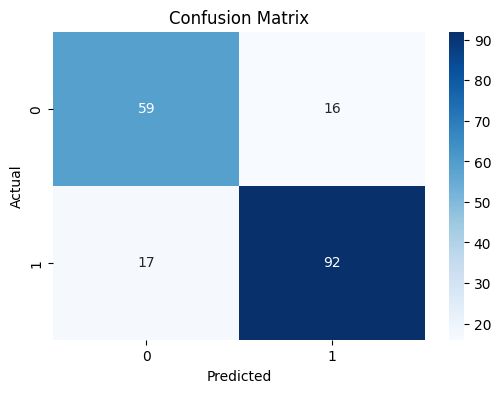

In [33]:
 from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [34]:
# Display model coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coef_df.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
9,dataset_Switzerland,1.045416
6,oldpeak,0.783888
7,sex_Male,0.666186
5,exang,0.475824
16,slope_flat,0.457593
0,age,0.187333
2,chol,0.158459
3,fbs,0.135115
17,slope_upsloping,0.075488
10,dataset_VA Long Beach,0.061217


The Logistic Regression model achieved an accuracy of 82% on the test dataset. The model correctly identified 92 patients with heart disease and 59 patients without heart disease. Recall for the positive class was 84%, indicating that most patients with heart disease were successfully detected. Precision was 85%, meaning that most positive predictions were correct. Overall, the model demonstrated good performance in predicting the presence of heart disease.